# 2. Distribution fitting

Fit a continuous **shadow rate** to daily Polymarket bin probabilities for the **front-month** FOMC contract.

1. Map each outcome token to rate-bin bounds (Regime 1 vs Regime 2 settlement rules).
2. Estimate Gaussian \((\mu, \sigma)\) and Student-t \((\mu, \sigma, \nu)\) by matching theoretical CDFs to market prices (L-BFGS-B).
3. Smooth parameters with a 5-day EWMA.
4. Compare models with AIC; also inspect a KDE baseline.

Reads `polymarket_fed_predictions_parsed.csv` and `fed_rates_and_futures.csv`. Writes:

- `daily_fed_rate_distribution_gaussian_estimation.csv`
- `daily_fed_rate_distribution_student_t_estimation.csv`

In [41]:
import requests
import pandas as pd
import time
import json
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import minimize


In [ ]:
df=pd.read_csv("polymarket_fed_predictions_parsed.csv")
df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
front_month_df = df.copy()
front_month_df.drop_duplicates(inplace=True)
rates_extended = pd.read_csv("fed_rates_and_futures.csv")
rates_extended['Date'] = pd.to_datetime(rates_extended['Date'])
df=pd.merge(front_month_df, rates_extended, on='Date', how='left')

In [ ]:
# front_month_df.to_csv("daily_fed_rate_distribution_gaussian_estimation.csv", index=False)

## Gaussian estimation (Regime 1 vs Regime 2 bin rules)

In [ ]:

rule_cutoff_date = pd.to_datetime('2025-03-19')

def get_mathematical_bounds(row):
    base_rate = row['Actual_Fed_Rate']
    shift = row['Rate_Shift']
    is_new_rules = row['Date'] > rule_cutoff_date
    
    if is_new_rules:
        # NEW RULES (May 2025 onwards): Standard 25 bps rounding bins
        half_step = 0.125
        target = base_rate + shift
        if row['Bin_Type'] == 'Lower_Bound': return (-np.inf, target + half_step)
        elif row['Bin_Type'] == 'Upper_Bound': return (target - half_step, np.inf)
        else: return (target - half_step, target + half_step)
            
    else:
        # OLD RULES (March 2025 and earlier)
        eps = 0.0625 
        
        if shift == 0: 
            return (base_rate - eps, base_rate + eps)
            
        elif shift < 0: 
            if row['Bin_Type'] == 'Lower_Bound': 
                return (-np.inf, base_rate + shift - eps)
            else: 
                # "25 bps decrease" -> covers from -31.25 bps up to -6.25 bps
                return (base_rate + shift - eps, base_rate + shift + 0.25 - eps)
                
        elif shift > 0: 
            if row['Bin_Type'] == 'Upper_Bound': 
                # "25+ bps increase" -> covers anything above +6.25 bps
                return (base_rate + eps, np.inf)
            else: 
                return (base_rate + shift - 0.25 + eps, base_rate + shift + eps)


In [46]:
front_month_df['Math_Bounds'] = front_month_df.apply(get_mathematical_bounds, axis=1)

In [ ]:
from scipy.optimize import minimize
from scipy.stats import t as student_t

def fit_tdist_cdf_time_series(bounds, market_probs):
    def loss_function(params):
        mu, sigma, nu = params
        
        theoretical_probs = []
        for lower, upper in bounds:
            # We use student_t instead of norm, and pass the 'df' (degrees of freedom)
            p_upper = student_t.cdf(upper, df=nu, loc=mu, scale=sigma)
            p_lower = student_t.cdf(lower, df=nu, loc=mu, scale=sigma)
            theoretical_probs.append(p_upper - p_lower)
            
        return np.sum((np.array(theoretical_probs) - market_probs)**2)

    rough_centers = [np.mean([l if l != -np.inf else u - 0.125, u if u != np.inf else l + 0.125]) for l, u in bounds]
    guess_mu = np.sum(np.array(rough_centers) * market_probs)
    guess_sigma = 0.25 
    guess_nu = 5.0 # Start with relatively fat tails

    # Bounds for L-BFGS-B:
    # nu is bound between 2 (extremely fat tails) and 50 (close to Normal distribution)
    bnds = ((guess_mu - 0.75, guess_mu + 0.75), (0.01, 2.0), (2.0, 50.0))

    result = minimize(
        loss_function, 
        x0=[guess_mu, guess_sigma, guess_nu], 
        method='L-BFGS-B', 
        bounds=bnds
    )
    
    if result.success:
        return result.x[0], result.x[1], result.x[2] # Returns mu, sigma, and nu
    return np.nan, np.nan, np.nan

def fit_distribution_cdf_time_series(bounds, market_probs):
    def loss_function(params):
        mu, sigma = params
        
        theoretical_probs = []
        for lower, upper in bounds:
            p_upper = norm.cdf(upper, loc=mu, scale=sigma)
            p_lower = norm.cdf(lower, loc=mu, scale=sigma)
            theoretical_probs.append(p_upper - p_lower)
            
        return np.sum((np.array(theoretical_probs) - market_probs)**2)

    #  common-sense baseline (the heuristic)
    rough_centers = [np.mean([l if l != -np.inf else u - 0.125, u if u != np.inf else l + 0.125]) for l, u in bounds]
    guess_mu = np.sum(np.array(rough_centers) * market_probs)
    
    # Estimate a starting sigma, ensuring it's not zero
    variance = np.sum(market_probs * (np.array(rough_centers) - guess_mu)**2)
    guess_sigma = max(np.sqrt(variance), 0.1) 

    # gaurdrails
    # Force mu to stay within +/- 0.75 (75 bps) of our common-sense guess.
    # Force sigma to be between 0.01 and 2.0 (preventing infinite flattening).
    bnds = ((guess_mu - 0.75, guess_mu + 0.75), (0.01, 2.0))

    # 3. Use L-BFGS-B, which respects boundaries
    result = minimize(
        loss_function, 
        x0=[guess_mu, guess_sigma], 
        method='L-BFGS-B', 
        bounds=bnds
    )
    
    # Sanity Check: If it just hugged the absolute edge of the boundary, it failed to find a real curve.
    if result.success:
        opt_mu, opt_sigma = result.x[0], result.x[1]
        if abs(opt_mu - guess_mu) >= 0.74: # it hit the guardrail
            return np.nan, np.nan
        return opt_mu, opt_sigma
        
    return np.nan, np.nan



In [48]:
front_month_df = df.copy() # Assuming your cleaned data is in 'df'
daily_params = []
all_dates = front_month_df['Date'].sort_values().unique()

print(f"Processing {len(all_dates)} days of market data...")

# PCalculate bounds for the entire dataframe at once before looping
front_month_df['Math_Bounds'] = front_month_df.apply(get_mathematical_bounds, axis=1)

Processing 1090 days of market data...


In [ ]:
for date in all_dates:
    day_data = front_month_df[front_month_df['Date'] == date].copy()
    
    if len(day_data) < 2:
        continue
        
    raw_probs = day_data['Implied_Probability'].values
    probs = raw_probs / np.sum(raw_probs) 
    
    bounds = day_data['Math_Bounds'].tolist()
    
    mu, sigma = fit_distribution_cdf_time_series(bounds, probs)
    
    # Fallback Mechanism
    if np.isnan(mu) or np.isnan(sigma):
        print(f"Optimization failed for date {date}. Using regime-adjusted heuristic.")
        
        # DYNAMIC FALLBACK: We extract the centers from the bounds themselves, 
        # ensuring the heuristic respects the Old vs. New rules perfectly.
        centers = np.array([np.mean([l if l != -np.inf else u - 0.125, u if u != np.inf else l + 0.125]) for l, u in bounds])
        
        mu = np.sum(centers * probs)
        sigma = np.sqrt(np.sum(probs * (centers - mu)**2))
    
    # Apply a strict floor to sigma to prevent infinite spikes
    # 0.08 prevents the curve from turning into a sheer cliff on highly certain days.
    sigma = max(sigma, 0.08)
    daily_params.append({
        'Date': date, 
        'raw_mu': mu, 
        'raw_sigma': sigma 
    })

Optimization failed for date 2026-03-19 00:00:00. Using regime-adjusted heuristic.


In [50]:
params_df = pd.DataFrame(daily_params).set_index('Date').sort_index()

# EWMA smoothing heavily weights the last 5 days
params_df['smoothed_mu'] = params_df['raw_mu'].ewm(span=5, adjust=False).mean()
params_df['smoothed_sigma'] = params_df['raw_sigma'].ewm(span=5, adjust=False).mean()

front_month_df = front_month_df.merge(params_df, left_on='Date', right_index=True, how='left')

In [ ]:
# front_month_df.to_csv("test_data.csv", index=False)

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\m'
C:\Users\steph\AppData\Local\Temp\ipykernel_26848\4066124993.py:12: SyntaxWarning: invalid escape sequence '\s'
  label='$\sigma$ Band'
C:\Users\steph\AppData\Local\Temp\ipykernel_26848\4066124993.py:16: SyntaxWarning: invalid escape sequence '\m'
  sns.lineplot(data=df_plot, x='Date', y='smoothed_mu', color='blue', label='Mean ($\mu$)')


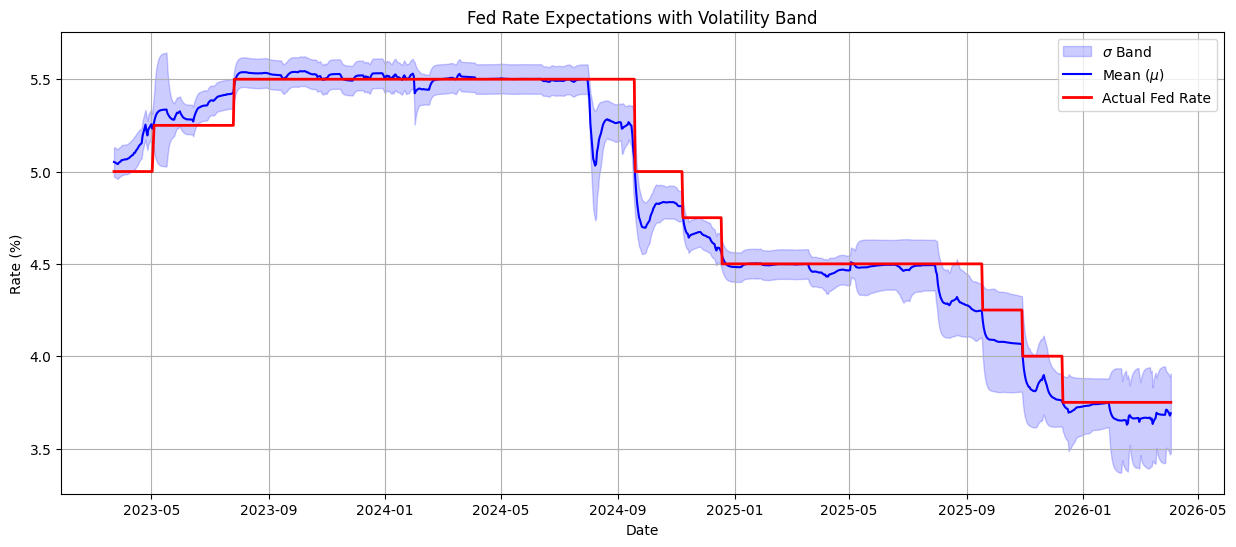

In [ ]:
df_plot = front_month_df.groupby('Date')[['smoothed_mu', 'Actual_Fed_Rate', 'smoothed_sigma']].mean().reset_index()

plt.figure(figsize=(15, 6))

#  Confidence Interval 
plt.fill_between(
    df_plot['Date'], 
    df_plot['smoothed_mu'] - df_plot['smoothed_sigma'], 
    df_plot['smoothed_mu'] + df_plot['smoothed_sigma'], 
    color='blue', 
    alpha=0.2, 
    label='$\sigma$ Band'
)

sns.lineplot(data=df_plot, x='Date', y='smoothed_mu', color='blue', label='Mean ($\mu$)')

sns.lineplot(data=df_plot, x='Date', y='Actual_Fed_Rate', color='red', label='Actual Fed Rate', linewidth=2)

plt.title("Fed Rate Expectations with Volatility Band")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid()
plt.show()

In [36]:
front_month_df.to_csv("daily_fed_rate_distribution_gaussian_estimation.csv", index=False)

## Student-t estimation

In [ ]:
front_month_df = df.copy()
daily_params = []
all_dates = front_month_df['Date'].sort_values().unique()

print(f"Processing {len(all_dates)} days of market data...")

front_month_df['Math_Bounds'] = front_month_df.apply(get_mathematical_bounds, axis=1)

Processing 1090 days of market data...


In [ ]:
for date in all_dates:
    day_data = front_month_df[front_month_df['Date'] == date].copy()
    
    if len(day_data) < 2:
        continue
        

    raw_probs = day_data['Implied_Probability'].values
    probs = raw_probs / np.sum(raw_probs) 
    
    bounds = day_data['Math_Bounds'].tolist()
    
    mu, sigma, nu = fit_tdist_cdf_time_series(bounds, probs)
    
    # Fallback Mechanism
    if np.isnan(mu) or np.isnan(sigma) or np.isnan(nu):
        print(f"Optimization failed for date {date}. Using regime-adjusted heuristic.")
        
        # DYNAMIC FALLBACK: We extract the centers from the bounds themselves, 
        # ensuring the heuristic respects the Old vs. New rules perfectly.
        centers = np.array([np.mean([l if l != -np.inf else u - 0.125, u if u != np.inf else l + 0.125]) for l, u in bounds])
        
        mu = np.sum(centers * probs)
        sigma = np.sqrt(np.sum(probs * (centers - mu)**2))
    
    # Apply a strict floor to sigma to prevent infinite spikes
    # 0.08 prevents the curve from turning into a sheer cliff on highly certain days.
    sigma = max(sigma, 0.08)
    nu = max(nu, 3.00)  # Ensure nu is sufficiently large for the t-distribution

    daily_params.append({
        'Date': date, 
        'raw_mu': mu, 
        'raw_sigma': sigma,
        'raw_nu': nu
    })

In [ ]:
params_df = pd.DataFrame(daily_params).set_index('Date').sort_index()

params_df['smoothed_mu'] = params_df['raw_mu'].ewm(span=5, adjust=False).mean()
params_df['smoothed_sigma'] = params_df['raw_sigma'].ewm(span=5, adjust=False).mean()
params_df['smoothed_nu'] = params_df['raw_nu'].ewm(span=5, adjust=False).mean()

front_month_df = front_month_df.merge(params_df, left_on='Date', right_index=True, how='left')

In [50]:
front_month_df['smoothed_nu'].min()

np.float64(3.0)

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\m'
C:\Users\steph\AppData\Local\Temp\ipykernel_31972\3768673003.py:12: SyntaxWarning: invalid escape sequence '\s'
  label='$\sigma$ Band'
C:\Users\steph\AppData\Local\Temp\ipykernel_31972\3768673003.py:16: SyntaxWarning: invalid escape sequence '\m'
  sns.lineplot(data=df_plot, x='Date', y='smoothed_mu', color='blue', label='Mean ($\mu$)')


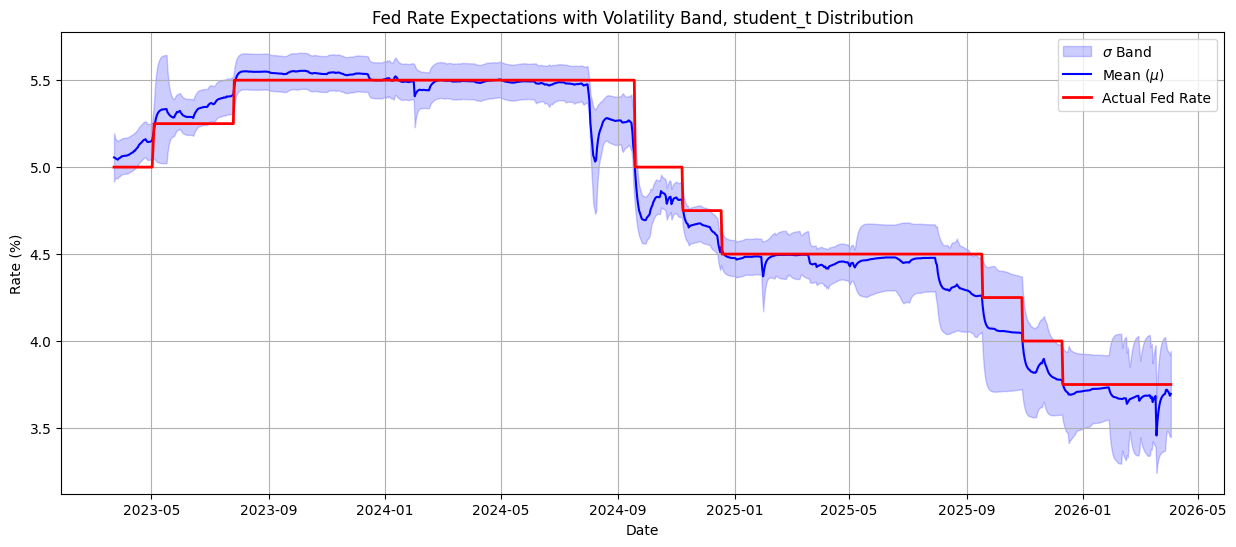

In [ ]:

df_plot = front_month_df.groupby('Date')[['smoothed_mu', 'Actual_Fed_Rate', 'smoothed_sigma','smoothed_nu']].mean().reset_index()
df_plot['true_sd'] = df_plot['smoothed_sigma'] * np.sqrt(df_plot['smoothed_nu'] / (df_plot['smoothed_nu'] - 2))
plt.figure(figsize=(15, 6))

plt.fill_between(
    df_plot['Date'], 
    df_plot['smoothed_mu'] - df_plot['true_sd'], 
    df_plot['smoothed_mu'] + df_plot['true_sd'],
    color='blue', 
    alpha=0.2, 
    label='$\sigma$ Band'
)

sns.lineplot(data=df_plot, x='Date', y='smoothed_mu', color='blue', label='Mean ($\mu$)')

sns.lineplot(data=df_plot, x='Date', y='Actual_Fed_Rate', color='red', label='Actual Fed Rate', linewidth=2)

plt.title("Fed Rate Expectations with Volatility Band, student_t Distribution")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid()
plt.show()

In [54]:
front_month_df.to_csv("daily_fed_rate_distribution_student_t_estimation.csv", index=False)

In [10]:
test1=df.loc[df['Event_Slug']=='fed-decision-in-december',['Date','Implied_Fed_Rate_Target','Implied_Probability']].drop_duplicates()
test1 = test1.pivot(index='Date', columns='Implied_Fed_Rate_Target', values='Implied_Probability')

In [ ]:
def get_gaussian_params(bins, weights):
    mu = np.sum(bins * weights)
    sigma = np.sqrt(np.sum(weights * (bins - mu)**2))
    return mu, max(sigma, 0.001) # Avoid zero sigma

In [ ]:
bin_centers = test1.columns.astype(float).values

x_fine = np.linspace(3.25, 4.5, 100)   # The range of values (X-axis)
y_time = np.arange(len(test1))           # Timesteps (Y-axis)
X, Y = np.meshgrid(x_fine, y_time)
Z = np.zeros(X.shape)                 # Density (Z-axis)

# for i in range(len(test1)):
#     weights = test1.iloc[i].values
#     # bw_method=0.3 provides a balance between smoothness and data fidelity
#     kde = gaussian_kde(bin_centers, weights=weights, bw_method=0.6)
#     Z[i, :] = kde(x_fine)

for i in range(len(test1)):
    weights = test1.iloc[i].values
    # bw_method=0.3 provides a balance between smoothness and data fidelity
    mu, sigma = get_gaussian_params(bin_centers, weights=weights)
    # kde = norm(loc=mu, scale=sigma)
    Z[i, :] = norm.pdf(x_fine, mu, sigma)

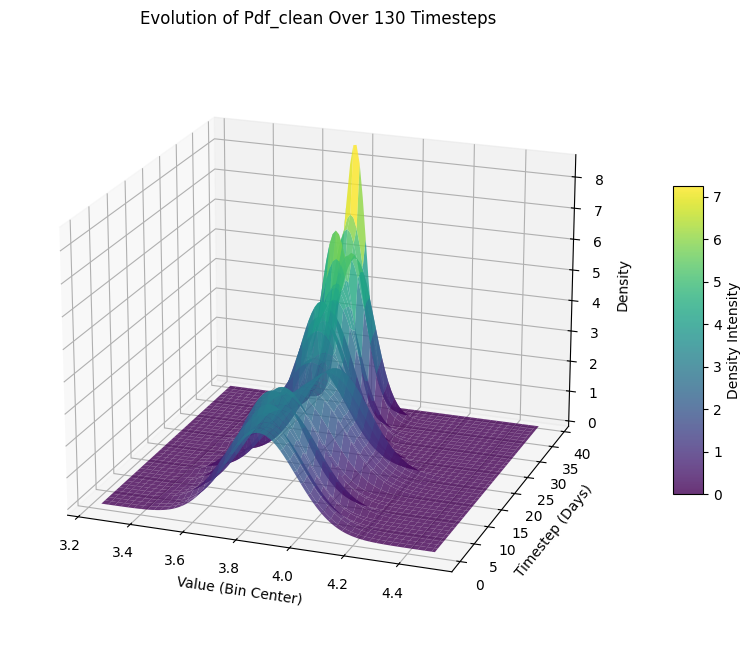

In [34]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)

ax.set_xlabel('Value (Bin Center)')
ax.set_ylabel('Timestep (Days)')
ax.set_zlabel('Density')
ax.set_title('Evolution of Pdf_clean Over 130 Timesteps')

# View angle: adjusting 'azim' helps see the "front" of the mountain range
ax.view_init(elev=20, azim=-70)

fig.colorbar(surf, shrink=0.5, aspect=10, label='Density Intensity')
plt.show()

In [24]:
from scipy.stats import gaussian_kde, expon

# Define your real bin edges
# [3.375-3.625], [3.625-3.875], [3.875-4.125], [4.125-inf]
bin_edges = [3.375, 3.625, 3.875, 4.125]

# To model the infinite bin, we generate "synthetic" points 
# that follow a distribution starting at the last edge (4.125)
tail_samples = np.linspace(4.125, 5.5, 20) 
# Use an exponential decay to weight the tail samples
tail_weights = expon.pdf(tail_samples, loc=4.125, scale=0.5) 

# Inside your loop:
for i in range(len(test1)):
    # 1. Take the weights for the first 3 "normal" bins
    inner_weights = test1.iloc[i].values[:-1]
    inner_centers = bin_centers[:-1]
    
    # 2. Take the weight of the +inf bin
    inf_bin_weight = test1.iloc[i].values[-1]
    
    # 3. Distribute that weight across the synthetic tail
    distributed_tail_weights = (tail_weights / tail_weights.sum()) * inf_bin_weight
    
    # 4. Combine
    combined_centers = np.concatenate([inner_centers, tail_samples])
    combined_weights = np.concatenate([inner_weights, distributed_tail_weights])
    
    kde = gaussian_kde(combined_centers, weights=combined_weights, bw_method=0.6)
    Z[i, :] = kde(x_fine)

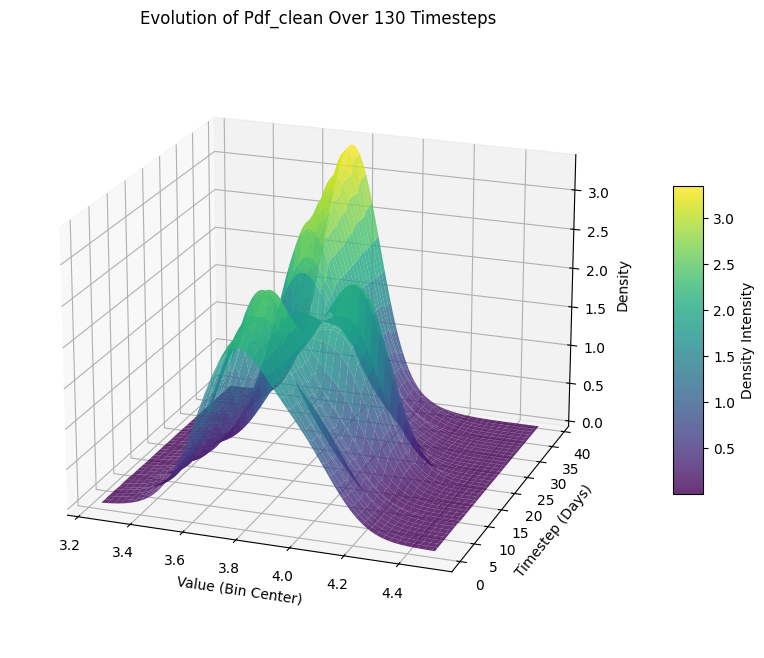

In [25]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)

ax.set_xlabel('Value (Bin Center)')
ax.set_ylabel('Timestep (Days)')
ax.set_zlabel('Density')
ax.set_title('Evolution of Pdf_clean Over 130 Timesteps')

# View angle: adjusting 'azim' helps see the "front" of the mountain range
ax.view_init(elev=20, azim=-70)

fig.colorbar(surf, shrink=0.5, aspect=10, label='Density Intensity')
plt.show()

## Model comparison (AIC)

In [56]:

rule_cutoff_date = pd.to_datetime('2025-03-19')

def calculate_information_criteria(sse, n, k):
    sse = max(sse, 1e-12) # avoid log(0)
    log_L = -(n / 2) * np.log(2 * np.pi) - (n / 2) * np.log(sse / n) - (n / 2)
    aic = 2 * k - 2 * log_L
    bic = k * np.log(n) - 2 * log_L
    return aic, bic

def get_mathematical_bounds(row):
    base_rate = row['Actual_Fed_Rate']
    shift = row['Rate_Shift']
    is_new_rules = row['Date'] > rule_cutoff_date
    
    if is_new_rules:
        half_step = 0.125
        target = base_rate + shift
        if row['Bin_Type'] == 'Lower_Bound': return (-np.inf, target + half_step)
        elif row['Bin_Type'] == 'Upper_Bound': return (target - half_step, np.inf)
        else: return (target - half_step, target + half_step)
            
    else:
        eps = 0.0625 
        
        if shift == 0: 
            return (base_rate - eps, base_rate + eps)
            
        elif shift < 0: 
            if row['Bin_Type'] == 'Lower_Bound': 
                return (-np.inf, base_rate + shift - eps)
            else: 
                return (base_rate + shift - eps, base_rate + shift + 0.25 - eps)
                
        elif shift > 0: 
            if row['Bin_Type'] == 'Upper_Bound': 
                return (base_rate + eps, np.inf)
            else: 
                return (base_rate + shift - 0.25 + eps, base_rate + shift + eps)


def fit_tdist_cdf_time_series(bounds, market_probs):
    def loss_function(params):
        mu, sigma, nu = params
        
        theoretical_probs = []
        for lower, upper in bounds:
            p_upper = student_t.cdf(upper, df=nu, loc=mu, scale=sigma)
            p_lower = student_t.cdf(lower, df=nu, loc=mu, scale=sigma)
            theoretical_probs.append(p_upper - p_lower)
            
        return np.sum((np.array(theoretical_probs) - market_probs)**2)

    rough_centers = [np.mean([l if l != -np.inf else u - 0.125, u if u != np.inf else l + 0.125]) for l, u in bounds]
    guess_mu = np.sum(np.array(rough_centers) * market_probs)
    guess_sigma = 0.25 
    guess_nu = 5.0 # Start with relatively fat tails

    bnds = ((guess_mu - 0.75, guess_mu + 0.75), (0.01, 2.0), (2.0, 50.0))

    result = minimize(
        loss_function, 
        x0=[guess_mu, guess_sigma, guess_nu], 
        method='L-BFGS-B', 
        bounds=bnds
    )
    
    if result.success:
        return result.x[0], result.x[1], result.x[2], result.fun 
    return np.nan, np.nan, np.nan, np.nan 

def fit_distribution_cdf_time_series(bounds, market_probs):
    def loss_function(params):
        mu, sigma = params
        
        theoretical_probs = []
        for lower, upper in bounds:
            p_upper = norm.cdf(upper, loc=mu, scale=sigma)
            p_lower = norm.cdf(lower, loc=mu, scale=sigma)
            theoretical_probs.append(p_upper - p_lower)
            
        return np.sum((np.array(theoretical_probs) - market_probs)**2)

    rough_centers = [np.mean([l if l != -np.inf else u - 0.125, u if u != np.inf else l + 0.125]) for l, u in bounds]
    guess_mu = np.sum(np.array(rough_centers) * market_probs)
    
    variance = np.sum(market_probs * (np.array(rough_centers) - guess_mu)**2)
    guess_sigma = max(np.sqrt(variance), 0.1) 

    bnds = ((guess_mu - 0.75, guess_mu + 0.75), (0.01, 2.0))

    result = minimize(
        loss_function, 
        x0=[guess_mu, guess_sigma], 
        method='L-BFGS-B', 
        bounds=bnds
    )
    
    if result.success:
        opt_mu, opt_sigma = result.x[0], result.x[1]
        if abs(opt_mu - guess_mu) >= 0.74: 
            return np.nan, np.nan, np.nan 
        return opt_mu, opt_sigma, result.fun 
        
    return np.nan, np.nan, np.nan 



In [65]:
front_month_df = df.copy() 
daily_params = []
all_dates = front_month_df['Date'].sort_values().unique()

print(f"Processing {len(all_dates)} days of market data...")

front_month_df['Math_Bounds'] = front_month_df.apply(get_mathematical_bounds, axis=1)

for date in all_dates:
    day_data = front_month_df[front_month_df['Date'] == date].copy()
    
    if len(day_data) < 2:
        continue
        
    n_bins = len(day_data) 
    
    raw_probs = day_data['Implied_Probability'].values
    probs = raw_probs / np.sum(raw_probs) 
    bounds = day_data['Math_Bounds'].tolist()
    
    mu_g, sigma_g, sse_g = fit_distribution_cdf_time_series(bounds, probs)
    mu_t, sigma_t, nu_t, sse_t = fit_tdist_cdf_time_series(bounds, probs)
    
    # calculate Information Criteria
    aic_g, bic_g = calculate_information_criteria(sse_g, n=n_bins, k=2) if not np.isnan(sse_g) else (np.nan, np.nan)
    aic_t, bic_t = calculate_information_criteria(sse_t, n=n_bins, k=3) if not np.isnan(sse_t) else (np.nan, np.nan)


    # Calculate the heuristic backup just in case either model fails
    centers = np.array([np.mean([l if l != -np.inf else u - 0.125, u if u != np.inf else l + 0.125]) for l, u in bounds])
    heur_mu = np.sum(centers * probs)
    heur_sigma = np.sqrt(np.sum(probs * (centers - heur_mu)**2))
    
    if np.isnan(mu_g) or np.isnan(sigma_g):
        mu_g, sigma_g = heur_mu, heur_sigma
    sigma_g = max(sigma_g, 0.08) # Floor
        
    if np.isnan(mu_t) or np.isnan(sigma_t) or np.isnan(nu_t):
        mu_t, sigma_t = heur_mu, heur_sigma
        nu_t = 50.0 # If we have to guess, assume it's roughly Normal (high nu)
        
    sigma_t = max(sigma_t, 0.08)
    nu_t = max(nu_t, 3.00) 
    
    daily_params.append({
        'Date': date, 
        'raw_mu': mu_g, 
        'raw_sigma': sigma_g,
        'Student_T_mu': mu_t, 
        'Student_T_sigma': sigma_t,
        'Student_T_nu': nu_t,
        'Gaussian_AIC': aic_g,
        'Gaussian_BIC': bic_g,
        'Student_T_AIC': aic_t,
        'Student_T_BIC': bic_t
    })

params_df = pd.DataFrame(daily_params).set_index('Date').sort_index()

params_df['smoothed_mu'] = params_df['Student_T_mu'].ewm(span=5, adjust=False).mean()
params_df['smoothed_sigma'] = params_df['Student_T_sigma'].ewm(span=5, adjust=False).mean()
params_df['smoothed_nu'] = params_df['Student_T_nu'].ewm(span=5, adjust=False).mean()

front_month_df = front_month_df.merge(params_df, left_on='Date', right_index=True, how='left')



Processing 1090 days of market data...


In [17]:
print(f"Average Gaussian AIC:  {params_df['Gaussian_AIC'].mean():.2f}")
print(f"Average Student-t AIC: {params_df['Student_T_AIC'].mean():.2f}")
print(f"Average Gaussian BIC:  {params_df['Gaussian_BIC'].mean():.2f}")
print(f"Average Student-t BIC: {params_df['Student_T_BIC'].mean():.2f}")

Average Gaussian AIC:  -18.02
Average Student-t AIC: -20.18
Average Gaussian BIC:  -18.81
Average Student-t BIC: -21.36


<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\steph\AppData\Local\Temp\ipykernel_26848\4283074837.py:20: SyntaxWarning: invalid escape sequence '\s'
  label='$\sigma$ Band'
C:\Users\steph\AppData\Local\Temp\ipykernel_26848\4283074837.py:24: SyntaxWarning: invalid escape sequence '\m'
  sns.lineplot(data=df_plot, x='Date', y='smoothed_mu', color='blue', label='Mean ($\mu$)')


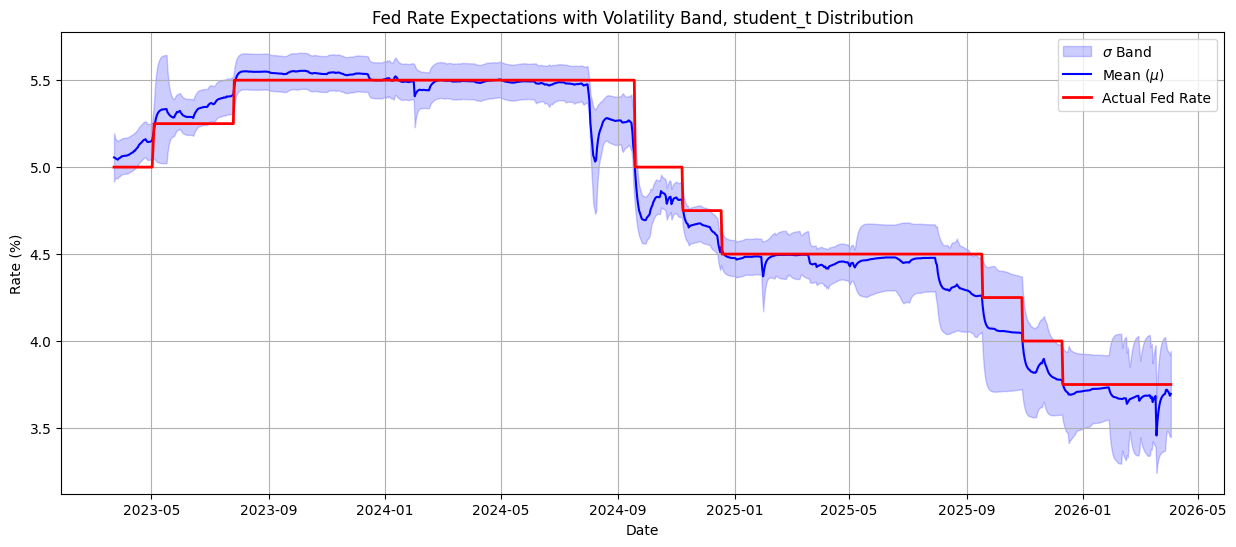

In [ ]:

df_plot = front_month_df.groupby('Date')[['smoothed_mu', 'Actual_Fed_Rate', 'smoothed_sigma','smoothed_nu']].mean().reset_index()
df_plot['true_sd'] = df_plot['smoothed_sigma'] * np.sqrt(df_plot['smoothed_nu'] / (df_plot['smoothed_nu'] - 2))
plt.figure(figsize=(15, 6))

plt.fill_between(
    df_plot['Date'], 
    df_plot['smoothed_mu'] - df_plot['true_sd'], 
    df_plot['smoothed_mu'] + df_plot['true_sd'],
    color='blue', 
    alpha=0.2, 
    label='$\sigma$ Band'
)

sns.lineplot(data=df_plot, x='Date', y='smoothed_mu', color='blue', label='Mean ($\mu$)')

sns.lineplot(data=df_plot, x='Date', y='Actual_Fed_Rate', color='red', label='Actual Fed Rate', linewidth=2)

plt.title("Fed Rate Expectations with Volatility Band, student_t Distribution")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid()
plt.show()

In [ ]:


def plot_3d_pdf_evolution(df):
    """
    Constructs and plots a 3D surface of the Student-t probability density functions over time.
    Requires the dataframe to have 'Student_T_mu', 'Student_T_sigma', and 'Student_T_nu'.
    """
    print("Preparing 3D Probability Surface...")
    

    plot_df = df.dropna(subset=['Student_T_mu', 'Student_T_sigma', 'Student_T_nu']).copy()
    plot_df.index = pd.to_datetime(plot_df.index)
    
    valid_dates = plot_df.index.strftime('%Y-%m-%d').values
    

    x_min = plot_df['Student_T_mu'].min() - 0.75  # Add a buffer for the tails
    x_max = plot_df['Student_T_mu'].max() + 0.75
    x_fine = np.linspace(x_min, x_max, 200) # 200 points for a smooth curve
    
    daily_distributions = []
    
    for _, row in plot_df.iterrows():
        mu = row['Student_T_mu']
        sigma = row['Student_T_sigma']
        nu = row['Student_T_nu']
        
        pdf_values = student_t.pdf(x_fine, df=nu, loc=mu, scale=sigma)
        daily_distributions.append(pdf_values)
        
    Z = np.array(daily_distributions)
    
    Y_time = np.arange(len(valid_dates))
    X, Y = np.meshgrid(x_fine, Y_time)
    
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(X, Y, Z, cmap='magma', edgecolor='none', alpha=0.9)
    
    ax.set_xlabel('\nImplied Fed Rate Target (%)', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel('\nTime (Days)', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_zlabel('\nProbability Density', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_title('Evolution of Market-Implied Fed Rates Over Time\n(Student-t Probability Density Surface)', fontsize=16, fontweight='bold', pad=20)
    
    step = max(1, len(valid_dates) // 6) # Pick 6 evenly spaced dates to prevent overlapping text
    tick_indices = np.arange(0, len(valid_dates), step)
    tick_labels = [valid_dates[i] for i in tick_indices]
    
    ax.yaxis.set_ticks(tick_indices)
    ax.yaxis.set_ticklabels(tick_labels, rotation=15, ha='right')
    
    ax.view_init(elev=25, azim=-115) 
    
    fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1, label='Density Height')
    
    plt.tight_layout()
    plt.show()



Preparing 3D Probability Surface...


C:\Users\steph\AppData\Local\Temp\ipykernel_26848\1279350779.py:68: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


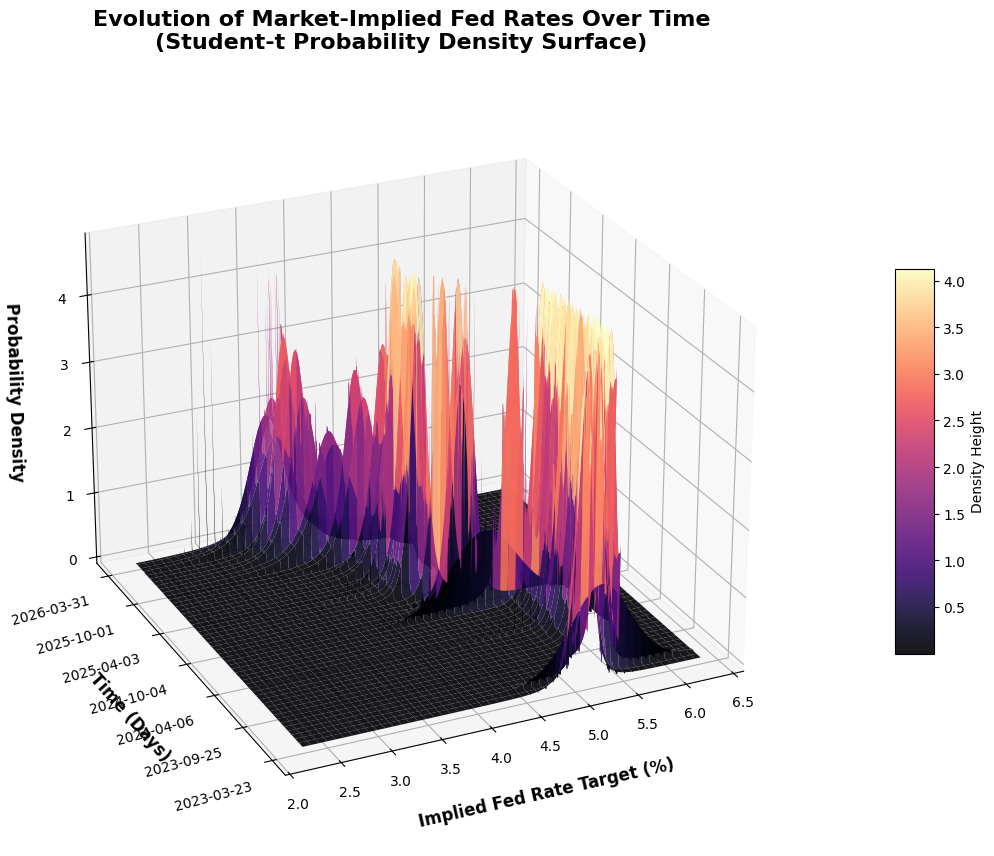

In [63]:

plot_3d_pdf_evolution(params_df)